# Bank Customer Churn: $185.6M in Deposits Walked Out the Door

**Author:** Jithma Kamburugamuwa

Most churn notebooks on this dataset train a classifier and report accuracy. **This one doesn't model at all.**

Instead it asks the question a bank executive would actually ask: *how much money left, and which customers took it with them?* The output is a set of segments a retention team could act on next quarter, sized in dollars.

Modeling is a natural next step, noted at the end, but a model that predicts churn without knowing which churn is expensive tells you where to look, not where to spend.

---

**The four findings:**

1. **20.37%** of customers churned. That is 2,037 accounts holding **\$185.6M**, or 24.3% of all deposits.
2. **Germany churns at 32.44%**, double France and Spain, while holding the *highest* average balances.
3. **Ages 46-60 churn at 51.12%**, driving **\$75M** in outflows.
4. **Inactive members churn at 26.85% vs 14.27% for active**. This is the clearest operational lever.

---

*Part of a full end-to-end project: BigQuery SQL → Python EDA → deployed Streamlit dashboard.*
*[GitHub repository](https://github.com/jithmak/banking-churn-analytics) · [Live dashboard](https://banking-churn-analytics-vdqy4jkpjivkhkjg2g8bcg.streamlit.app)*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# matplotlib renders straight to PNG, so the charts are visible to every reader
# (Kaggle's public view, GitHub, mobile) with no extra backend or internet access.
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.figsize': (11, 6), 'figure.dpi': 110,
                     'axes.titlesize': 14, 'axes.titleweight': 'bold'})
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

CSV_NAME = 'Bank Customer Churn Prediction.csv'
KAGGLE_INPUT = Path('/kaggle/input')


def locate_dataset():
    """Find the CSV on Kaggle (any attached-dataset folder) or in the local repo."""
    if not KAGGLE_INPUT.exists():                      # running locally
        return Path('data/raw') / CSV_NAME

    candidates = sorted(KAGGLE_INPUT.glob('*/**/*.csv'))
    if not candidates:
        mounted = [p.name for p in KAGGLE_INPUT.iterdir()] or ['(nothing)']
        raise FileNotFoundError(
            'No CSV found under /kaggle/input.\n'
            'Attach the dataset first: the "+ Add Input" button in the right-hand\n'
            'sidebar, then search for "Bank Customer Churn Dataset" (by gauravtopre).\n'
            f'Currently attached: {mounted}'
        )
    exact = [c for c in candidates if c.name == CSV_NAME]
    return exact[0] if exact else candidates[0]


DATA_PATH = locate_dataset()
df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df):,} rows x {df.shape[1]} columns')
print(f'Source: {DATA_PATH}')
df.head()

Loaded 10,000 rows x 12 columns
Source: data/raw/Bank Customer Churn Prediction.csv


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,"101,348.88",1
1,15647311,608,Spain,Female,41,1,"83,807.86",1,0,1,"112,542.58",0
2,15619304,502,France,Female,42,8,"159,660.80",3,1,0,"113,931.57",1
3,15701354,699,France,Female,39,1,0.00,2,0,0,"93,826.63",0
4,15737888,850,Spain,Female,43,2,"125,510.82",1,1,1,"79,084.10",0


## 1. Data Integrity

Before any conclusion, confirm the data can support it.

In [2]:
print('Missing values :', df.isnull().sum().sum())
print('Duplicate rows  :', df.duplicated().sum())
print('Duplicate IDs   :', df['customer_id'].duplicated().sum())
print('Age range       :', df['age'].min(), '-', df['age'].max())

df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]

Missing values : 0
Duplicate rows  : 0
Duplicate IDs   : 0
Age range       : 18 - 92


,count,mean,std,min,50%,max
customer_id,"10,000.00","15,690,940.57","71,936.19","15,565,701.00","15,690,738.00","15,815,690.00"
credit_score,"10,000.00",650.53,96.65,350.00,652.00,850.00
age,"10,000.00",38.92,10.49,18.00,37.00,92.00
tenure,"10,000.00",5.01,2.89,0.00,5.00,10.00
balance,"10,000.00","76,485.89","62,397.41",0.00,"97,198.54","250,898.09"
products_number,"10,000.00",1.53,0.58,1.00,1.00,4.00
credit_card,"10,000.00",0.71,0.46,0.00,1.00,1.00
active_member,"10,000.00",0.52,0.50,0.00,1.00,1.00
estimated_salary,"10,000.00","100,090.24","57,510.49",11.58,"100,193.91","199,992.48"
churn,"10,000.00",0.20,0.40,0.00,0.00,1.00


**Clean:** no missing values, no duplicates, no repeated customer IDs. No imputation or de-duplication needed.

One structural feature matters enormously for everything that follows, so it is measured explicitly rather than assumed:

In [3]:
zero_bal = (df['balance'] == 0).sum()
print(f'Zero-balance accounts: {zero_bal:,} ({zero_bal / len(df):.1%} of the portfolio)')

print('\nZero-balance share by country:')
print(df.assign(is_zero=df['balance'].eq(0)).groupby('country')['is_zero'].mean().mul(100).round(1))

Zero-balance accounts: 3,617 (36.2% of the portfolio)

Zero-balance share by country:
country
France    48.20
Germany    0.00
Spain     48.40
Name: is_zero, dtype: float64


> **Caveat that shapes the whole analysis.** Over a third of accounts hold a zero balance, and they are *not* evenly spread. Germany has almost none. So Germany's "highest average balance" is substantially an artifact of this imbalance, not purely a sign of wealthier customers. Balance comparisons below should be read with that in mind.

## 2. The Headline: Churn Rate and Capital at Risk

Churn rate alone understates the problem. The number that matters is the **deposit balance leaving with those customers**.

In [4]:
n = len(df)
churned = int(df['churn'].sum())
churn_rate = churned / n * 100
lost_capital = df.loc[df['churn'] == 1, 'balance'].sum()
total_capital = df['balance'].sum()

print(f'Total customers      : {n:,}')
print(f'Churned customers    : {churned:,}')
print(f'Churn rate           : {churn_rate:.2f}%')
print(f'Capital lost         : ${lost_capital:,.2f}')
print(f'Share of deposits    : {lost_capital / total_capital:.2%}')

Total customers      : 10,000
Churned customers    : 2,037
Churn rate           : 20.37%
Capital lost         : $185,588,094.63
Share of deposits    : 24.26%


**2,037 customers took \$185.6M with them, 24.3% of the bank's deposit base against a 20.37% headcount loss.**

The customers leaving hold *more* than the average customer. Churn here is not a volume problem, it is a value problem.

## 3. Where Is It Concentrated?

Four segmentations, each reported with its sample size so the reader can judge how much weight a rate deserves.

In [5]:
def segment(frame, by, label=None):
    """Churn rate and lost capital for a segmentation, with sample sizes."""
    out = frame.groupby(by, observed=True).agg(
        customers=('churn', 'size'),
        churned=('churn', 'sum'),
        churn_rate_pct=('churn', lambda s: s.mean() * 100),
        avg_balance=('balance', 'mean'),
    )
    churned_only = frame[frame['churn'] == 1]
    lost = churned_only.groupby(by, observed=True)['balance'].sum()
    out['lost_capital'] = lost.reindex(out.index).fillna(0)
    out.index.name = label or by
    return out.round(2)


geo = segment(df, 'country', 'Country')
geo

,customers,churned,churn_rate_pct,avg_balance,lost_capital
Country,,,,,
France,5014,810,16.15,"62,092.64","57,666,164.54"
Germany,2509,814,32.44,"119,730.12","97,973,915.53"
Spain,2477,413,16.67,"61,818.15","29,948,014.56"


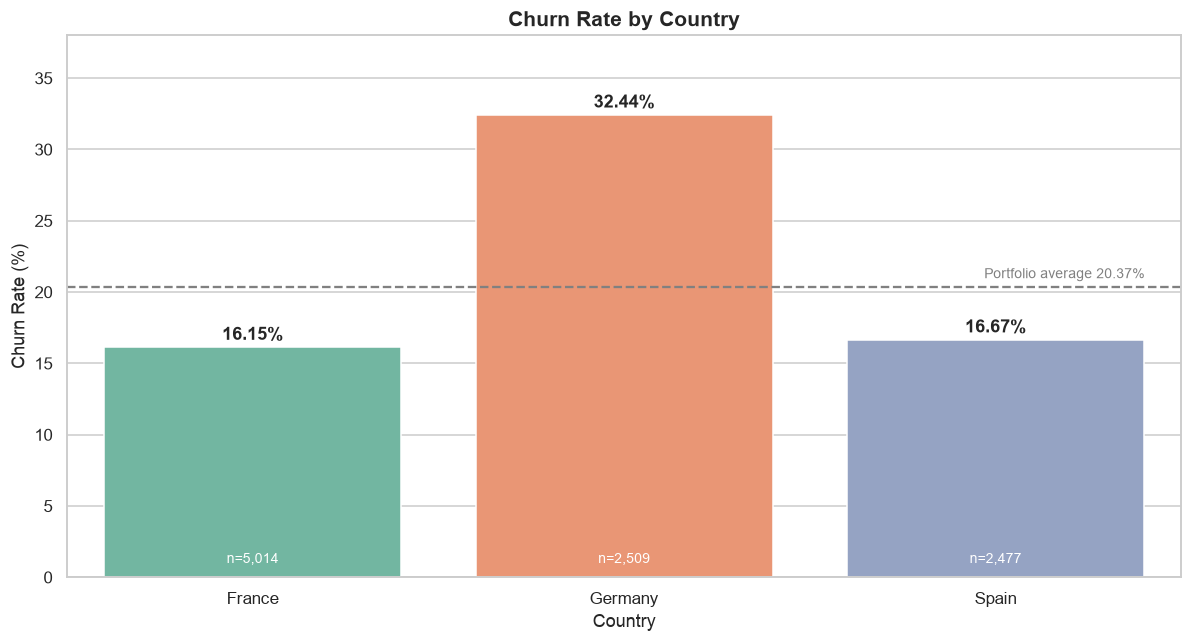

In [6]:
g = geo.reset_index()
ax = sns.barplot(data=g, x='Country', y='churn_rate_pct', hue='Country',
                 palette='Set2', legend=False)
for i, r in g.iterrows():
    ax.text(i, r['churn_rate_pct'] + 0.5, f"{r['churn_rate_pct']:.2f}%",
            ha='center', fontweight='bold')
    ax.text(i, 1, f"n={int(r['customers']):,}", ha='center', color='white', fontsize=9)
ax.axhline(churn_rate, ls='--', color='grey')
ax.text(2.4, churn_rate + 0.6, f'Portfolio average {churn_rate:.2f}%',
        ha='right', color='grey', fontsize=9)
ax.set(title='Churn Rate by Country', ylabel='Churn Rate (%)', ylim=(0, 38))
plt.tight_layout(); plt.show()

**Germany is the outlier: 32.44% churn (n=2,509), roughly double France (16.15%) and Spain (16.67%)**, while carrying the highest average balance at \$119.7k.

The bank's most valuable market is also its leakiest. Note that France, despite the lowest rate, contributes the largest *absolute* customer base (n=5,014), so it is not negligible in dollar terms.

In [7]:
bins = [17, 30, 45, 60, 200]
names = ['18-30 (Young Adult)', '31-45 (Mid Career)', '46-60 (Pre-Retirement)', '61+ (Retiree)']
df['age_bracket'] = pd.cut(df['age'], bins=bins, labels=names)

age_seg = segment(df, 'age_bracket', 'Age Bracket')
age_seg

,customers,churned,churn_rate_pct,avg_balance,lost_capital
Age Bracket,,,,,
18-30 (Young Adult),1968,148,7.52,"73,198.76","14,809,796.05"
31-45 (Mid Career),5921,932,15.74,"76,241.83","85,037,918.11"
46-60 (Pre-Retirement),1647,842,51.12,"81,500.48","75,172,453.58"
61+ (Retiree),464,115,24.78,"75,742.60","10,567,926.89"


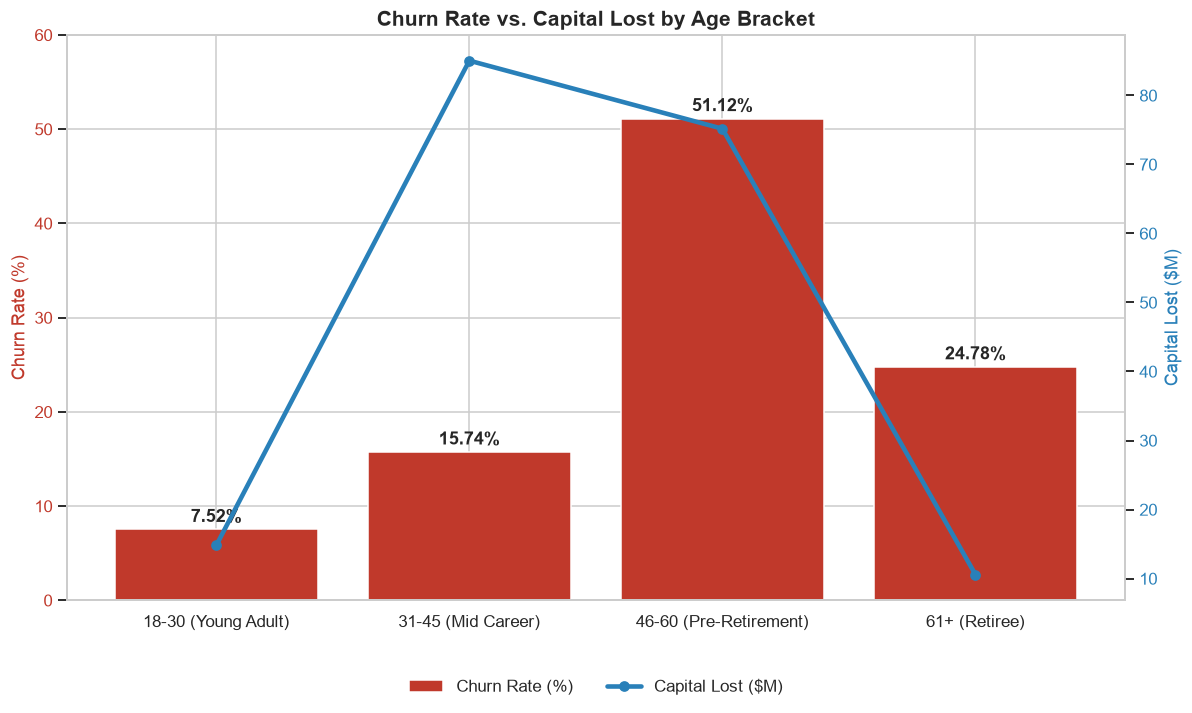

In [8]:
a = age_seg.reset_index()
fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.bar(a['Age Bracket'].astype(str), a['churn_rate_pct'], color='#c0392b',
        label='Churn Rate (%)')
for i, v in enumerate(a['churn_rate_pct']):
    ax1.text(i, v + 0.8, f'{v:.2f}%', ha='center', fontweight='bold')
ax1.set_ylabel('Churn Rate (%)', color='#c0392b')
ax1.tick_params(axis='y', labelcolor='#c0392b')
ax1.set_ylim(0, 60)

ax2 = ax1.twinx()
ax2.plot(a['Age Bracket'].astype(str), a['lost_capital'] / 1e6, color='#2980b9',
         marker='o', lw=3, label='Capital Lost ($M)')
ax2.set_ylabel('Capital Lost ($M)', color='#2980b9')
ax2.tick_params(axis='y', labelcolor='#2980b9')
ax2.grid(False)

ax1.set_title('Churn Rate vs. Capital Lost by Age Bracket')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False)
plt.tight_layout(); plt.show()

**Customers aged 46-60 churn at 51.12% (n=1,647), over half the bracket, releasing \$75.2M.**

The dual axis matters here. The 31-45 bracket has a far *lower* rate (15.74%) but is so much larger (n=5,921) that it leaks even more capital (\$85.0M). Rate identifies the sickest segment; absolute dollars identify the most expensive one. **They are different segments, and they call for different responses.**

In [9]:
prod = segment(df, 'products_number', 'Products Held')
prod

,customers,churned,churn_rate_pct,avg_balance,lost_capital
Products Held,,,,,
1,5084,1409,27.71,"98,551.87","129,668,607.08"
2,4590,348,7.58,"51,879.15","31,407,820.29"
3,266,220,82.71,"75,458.33","18,887,679.16"
4,60,60,100.00,"93,733.14","5,623,988.10"


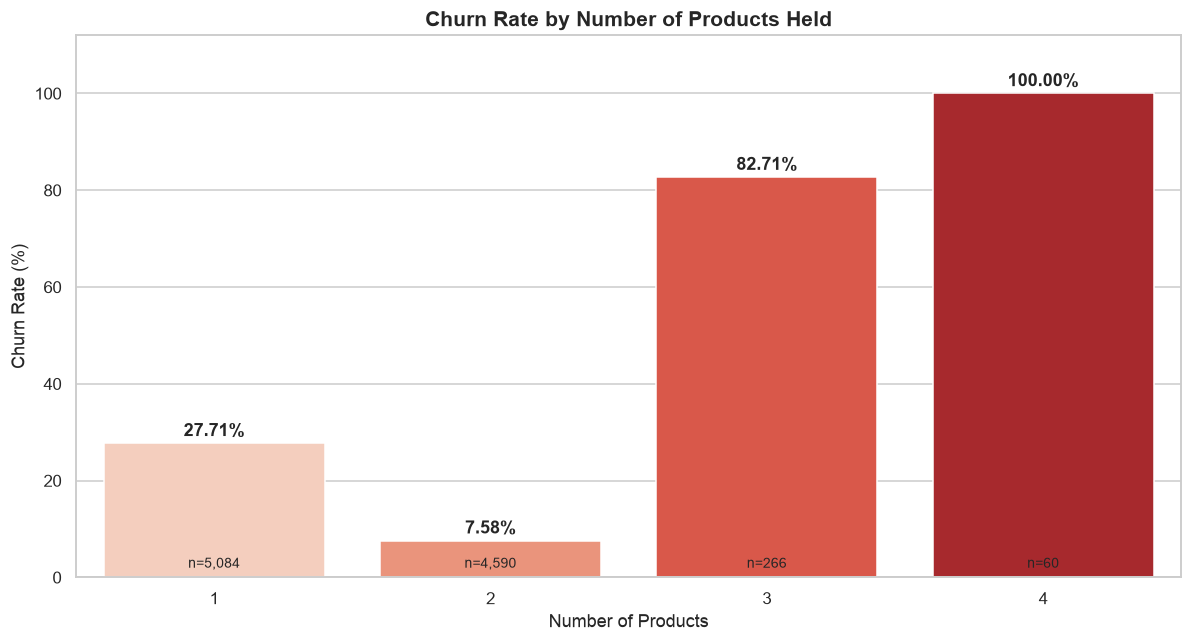

In [10]:
p = prod.reset_index()
p['label'] = p['Products Held'].astype(str)
ax = sns.barplot(data=p, x='label', y='churn_rate_pct', hue='label',
                 palette='Reds', legend=False)
for i, r in p.iterrows():
    ax.text(i, r['churn_rate_pct'] + 1.5, f"{r['churn_rate_pct']:.2f}%",
            ha='center', fontweight='bold')
    ax.text(i, 2, f"n={int(r['customers']):,}", ha='center', fontsize=9)
ax.set(title='Churn Rate by Number of Products Held',
       xlabel='Number of Products', ylabel='Churn Rate (%)', ylim=(0, 112))
plt.tight_layout(); plt.show()

This is the most dramatic chart in the notebook, and the one to be **most careful about.**

Churn hits **82.71% at 3 products and 100.00% at 4**. But look at the denominators: **n=266 and n=60**, together just 3.3% of the portfolio. A 100% rate on 60 customers is a strong signal, not a stable estimate; a handful of different outcomes would move it materially.

Read it as *"something is badly wrong in the 3+ product journey, go investigate"*, not as a reliable forecast. The genuinely actionable finding is the contrast between 1 product (27.71%, n=5,084) and 2 products (7.58%, n=4,590): **the second product is where retention is won**, and that rests on nearly 10,000 customers.

In [11]:
act = df.assign(status=df['active_member'].map({1: 'Active', 0: 'Inactive'}))
active_seg = segment(act, 'status', 'Membership')
active_seg

,customers,churned,churn_rate_pct,avg_balance,lost_capital
Membership,,,,,
Active,5151,735,14.27,"75,875.42","67,120,667.81"
Inactive,4849,1302,26.85,"77,134.38","118,467,426.82"


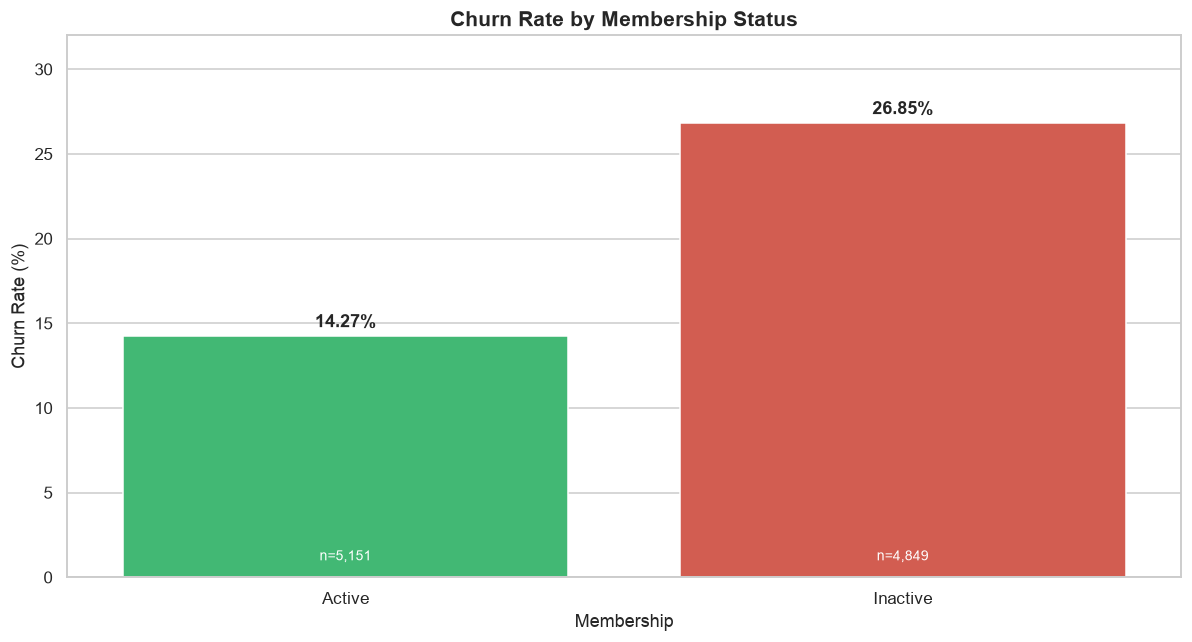

In [12]:
s = active_seg.reset_index()
ax = sns.barplot(data=s, x='Membership', y='churn_rate_pct', hue='Membership',
                 palette={'Active': '#2ecc71', 'Inactive': '#e74c3c'}, legend=False)
for i, r in s.iterrows():
    ax.text(i, r['churn_rate_pct'] + 0.5, f"{r['churn_rate_pct']:.2f}%",
            ha='center', fontweight='bold')
    ax.text(i, 1, f"n={int(r['customers']):,}", ha='center', color='white', fontsize=9)
ax.set(title='Churn Rate by Membership Status', ylabel='Churn Rate (%)', ylim=(0, 32))
plt.tight_layout(); plt.show()

**Inactive members churn at 26.85% vs 14.27% for active, a 1.9x gap**, and unlike the product finding this rests on a near even split (4,849 vs 5,151).

A note on interpretation: activity and retention are almost certainly **mutually reinforcing** rather than one causing the other. Disengagement precedes exit, and customers already intending to leave disengage first. This is still the most useful lever in the dataset. Inactivity is *observable early*, which makes it a practical trigger for intervention regardless of the causal direction.

## 4. Age Distribution and Correlations

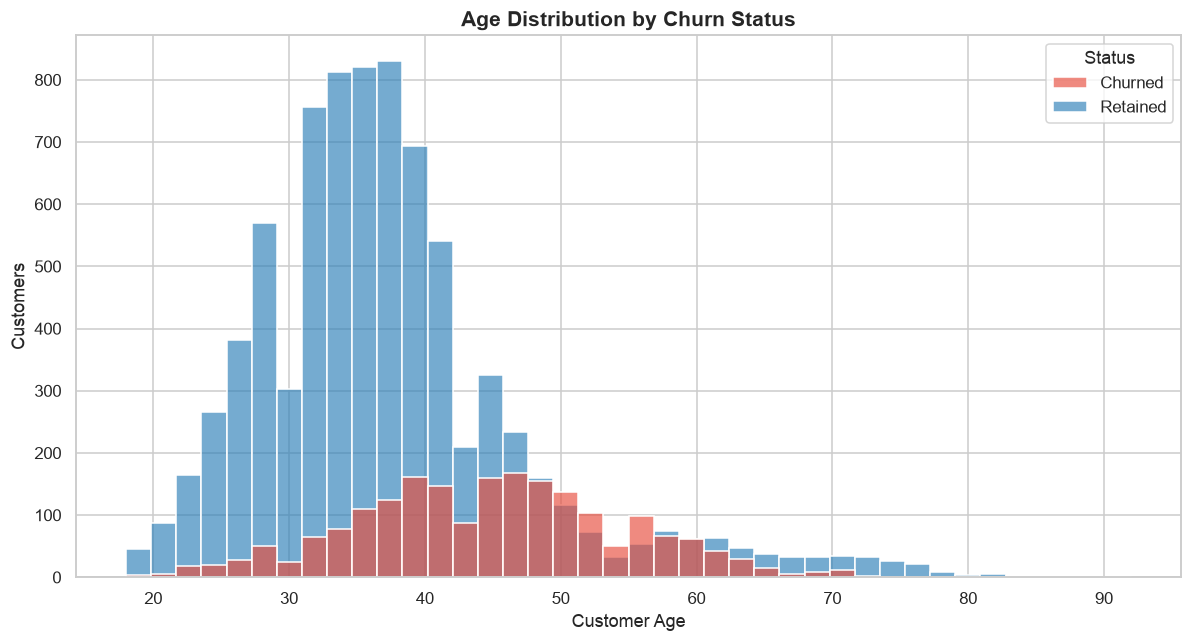

In [13]:
ax = sns.histplot(data=df.assign(Status=df['churn'].map({0: 'Retained', 1: 'Churned'})),
                  x='age', hue='Status', bins=40, multiple='layer', alpha=0.65,
                  palette={'Retained': '#2c7fb8', 'Churned': '#e74c3c'})
ax.set(title='Age Distribution by Churn Status', xlabel='Customer Age',
       ylabel='Customers')
plt.tight_layout(); plt.show()

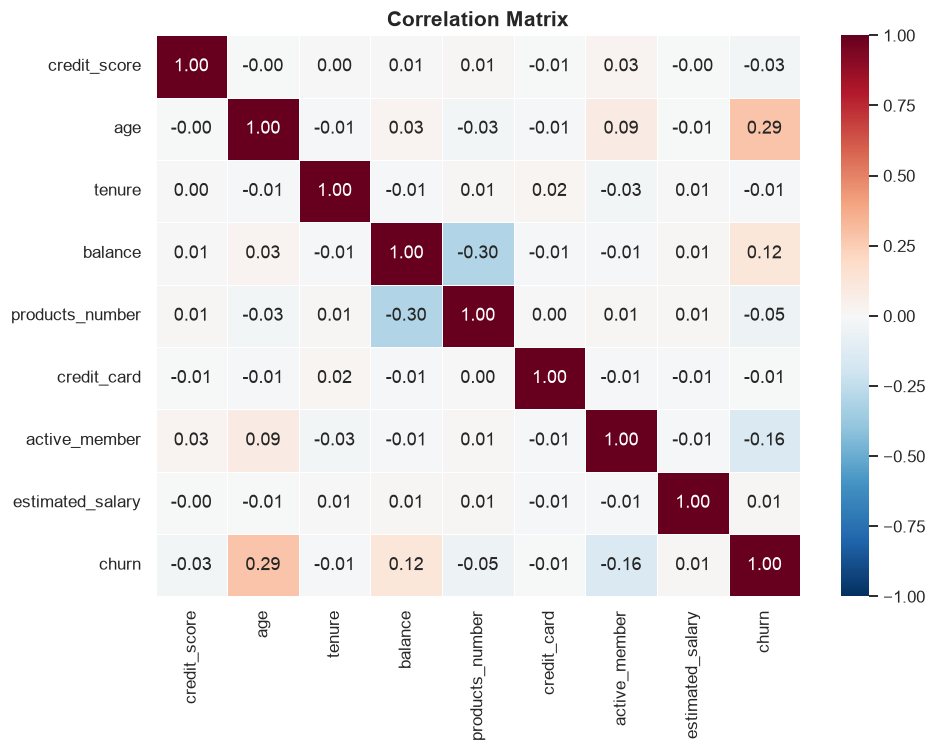

In [14]:
num = df.select_dtypes(include=[np.number]).drop(columns=['customer_id'])
corr = num.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            linewidths=0.5, square=False)
plt.title('Correlation Matrix')
plt.tight_layout(); plt.show()

In [15]:
corr_churn = corr['churn'].drop('churn').sort_values(ascending=False)
print('Linear correlation with churn:')
for name, val in corr_churn.items():
    print(f'  {name:<18} {val:+.3f}')

Linear correlation with churn:
  age                +0.285
  balance            +0.119
  estimated_salary   +0.012
  credit_card        -0.007
  tenure             -0.014
  credit_score       -0.027
  products_number    -0.048
  active_member      -0.156


Age is the strongest linear correlate (**+0.285**), with active membership next (**-0.156**). Everything else is near zero.

This is worth pausing on. Linear correlation is a poor instrument for the strongest effect in the entire dataset: the product relationship is **non-monotonic**. Churn falls from 1 to 2 products, then explodes at 3 and 4. A correlation coefficient averages that into approximately nothing (**-0.048**), which is why the segmentation above found what the correlation matrix cannot.

**A near-zero correlation is not evidence of no relationship.** It is evidence of no *linear* relationship.

## 5. The Warehouse Layer (BigQuery SQL)

In the full project, these segmentations were first produced in **Google BigQuery**, with the notebook used for validation and visualisation. The queries below target a private BigQuery table so they are not executable here. They are included as artifacts of the warehouse layer.

```sql
-- Executive portfolio KPIs
SELECT
    COUNT(customer_id) AS total_customers,
    SUM(churn) AS total_churned_customers,
    ROUND(AVG(churn) * 100, 2) AS churn_rate_pct,
    ROUND(SUM(CASE WHEN churn = 1 THEN balance ELSE 0 END), 2) AS total_capital_lost_usd
FROM `banking-churn-project.banking_analytics.bank_churn`;

-- Age bracket & high-value capital leakage
SELECT
    CASE
        WHEN age BETWEEN 18 AND 30 THEN '18-30 (Young Adult)'
        WHEN age BETWEEN 31 AND 45 THEN '31-45 (Mid Career)'
        WHEN age BETWEEN 46 AND 60 THEN '46-60 (Pre-Retirement)'
        ELSE '61+ (Retiree)'
    END AS age_bracket,
    COUNT(customer_id) AS total_customers,
    SUM(churn) AS churned_customers,
    ROUND(AVG(churn) * 100, 2) AS churn_rate_pct,
    ROUND(SUM(CASE WHEN churn = 1 THEN balance ELSE 0 END), 2) AS lost_balance
FROM `banking-churn-project.banking_analytics.bank_churn`
GROUP BY age_bracket
ORDER BY churn_rate_pct DESC;
```

The [full query set is on GitHub](https://github.com/jithmak/banking-churn-analytics/blob/main/sql/banking_churn_analysis.sql).

## 6. Recommendations

Ordered by evidence strength, not by drama.

| # | Action | Evidence | Confidence |
|---|---|---|---|
| 1 | **Drive single-product customers to a second product.** The 1 → 2 product step cuts churn from 27.71% to 7.58%. | n=5,084 and n=4,590 | High |
| 2 | **Trigger outreach on inactivity.** Inactive members churn at 1.9x active. Inactivity is observable *before* exit. | n=4,849 / n=5,151 | High |
| 3 | **Staff a German retention desk.** 32.44% churn on the highest-balance market. | n=2,509 | High |
| 4 | **Build a 46-60 pre-retirement proposition.** 51.12% churn, \$75.2M. Pair with 31-45, which leaks \$85.0M at a lower rate. | n=1,647 | High |
| 5 | **Audit the 3-4 product journey** for fee stacking or onboarding failure. | n=266 / n=60 | **Low. Investigate, do not budget against** |

## Limitations

Stated plainly, because they bound every number above.

- **No time dimension.** `churn` is a static flag with no exit date, so nothing here is a trend, a survival curve, or a causal estimate. These are cross-sectional associations.
- **Balance is a snapshot, not lifetime value.** "Capital at risk" is the deposit balance at observation. It is not profit, and departing customers may hold products elsewhere in the bank.
- **36% zero balances** distort every balance-weighted comparison, unevenly across countries.
- **Small segments.** The 3- and 4-product findings rest on 266 and 60 customers.
- **No cost data.** Recommendations are ranked by evidence, not ROI. Retention economics would require acquisition and servicing costs this dataset does not contain.

## Next Steps

The obvious extension is a **gradient-boosted classifier** for per-customer churn probability. The more useful one is to weight that model by **balance at risk**, so it ranks customers by *expected dollars saved* rather than by probability of leaving. A model that flags a \$0-balance customer and a \$150k customer with equal urgency has not solved the business problem.

---

*If this was useful, an upvote is appreciated. Questions and critique welcome in the comments.*

**[Full project on GitHub](https://github.com/jithmak/banking-churn-analytics)**. BigQuery SQL, EDA notebook, and a deployed Streamlit dashboard.